In [2]:
import matplotlib.pyplot as plt
import pickle

In [5]:
data = pickle.load(open('/home/cohenn1/NCE/notebooks/output.pkl', 'rb'))

In [6]:
data.keys()

dict_keys(['grid20x20.f2', 'pedigree18', 'rbm_20'])

In [13]:
traced_losses = ['from_logspace_gil1','from_logspace_gil1c', 'logspace_mse']
num_iters = 5

In [15]:
run = None
for problem_name in data.keys():
    for bucket in range(len(data[problem_name])//num_iters):
        for iter in range(num_iters):
            run = data[problem_name][bucket*num_iters + iter]
            break
        break
    break


In [23]:
x = [elt[0] for elt in run[1]]
ygil1 = [elt[1] for elt in run[1]]
ygil1c = [elt[2] for elt in run[1]]
ymse = [elt[3] for elt in run[1]]

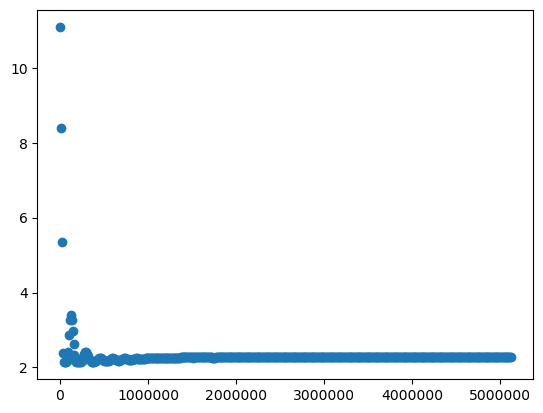

In [25]:
plt.scatter(x,ygil1)

In [5]:
import torch
from typing import List

In [7]:
def map_assignments_to_slices(assignments_tensor: torch.Tensor,
                               column_labels_assignments: List[int],
                               column_labels_factor: List[int],
                               summation_assignment: List[int],
                               summation_assignment_labels: List[int]) -> torch.Tensor:
    """
    Maps columns from assignments_tensor to a new tensor based on column_labels_factor.
    If a label in column_labels_factor is not found in column_labels_assignments,
    the corresponding column is populated from summation_assignment using summation_assignment_labels.

    Args:
        assignments_tensor (torch.Tensor): 2D tensor with shape (m, n_assignments)
        column_labels_assignments (list[int]): Labels for columns in assignments_tensor
        column_labels_factor (list[int]): Desired column labels for the output tensor
        summation_assignment (list[int]): List of values to populate columns for unmatched labels
        summation_assignment_labels (list[int]): Labels corresponding to summation_assignment values

    Returns:
        torch.Tensor: 2D tensor with shape (m, len(column_labels_factor))
    """
    # Ensure input tensor is 2D
    assert assignments_tensor.ndim == 2, "assignments_tensor must be 2-dimensional"

    # Prepare output tensor with shape (m, len(column_labels_factor))
    output_tensor = torch.zeros(assignments_tensor.size(0), len(column_labels_factor))

    # Create a mapping from column_labels_assignments to column indices
    assignments_label_to_index = {label: idx for idx, label in enumerate(column_labels_assignments)}

    # Create a mapping from summation_assignment_labels to values
    summation_label_to_value = {label: value for label, value in zip(summation_assignment_labels, summation_assignment)}

    # Iterate over column_labels_factor to populate the output tensor
    for i, slice_label in enumerate(column_labels_factor):
        if slice_label in assignments_label_to_index:
            # If the label exists in column_labels_assignments, use the corresponding column
            output_tensor[:, i] = assignments_tensor[:, assignments_label_to_index[slice_label]]
        elif slice_label in summation_label_to_value:
            # If the label exists in summation_assignment_labels, use the corresponding value
            output_tensor[:, i] = summation_label_to_value[slice_label]
        else:
            # If no matching label is found, raise an error
            raise ValueError(f"Label {slice_label} not found in column_labels_assignments or summation_assignment_labels")

    return output_tensor

# Example usage
assignments_tensor = torch.tensor([[1, 0, 0], [0, 1, 0], [1, 0, 1]])
column_labels_assignments = [1, 2, 3]
column_labels_factor = [3, 4, 2]
summation_assignment = [4]
summation_assignment_labels = [4]

result = map_assignments_to_slices(assignments_tensor, column_labels_assignments, column_labels_factor, summation_assignment, summation_assignment_labels)
print(result)

tensor([[0., 4., 0.],
        [0., 4., 1.],
        [1., 4., 0.]])


In [8]:
print(assignments_tensor)

tensor([[1, 0, 0],
        [0, 1, 0],
        [1, 0, 1]])


In [9]:
def fib():
    prev = 1
    current = 1
    while True:
        yield current
        prev, current = current, prev + current

In [16]:
f = fib()

In [20]:
next(f)

5

In [24]:
tensor = torch.arange(10)
tensor = tensor.view(10,1)
tensor

tensor([[0],
        [1],
        [2],
        [3],
        [4],
        [5],
        [6],
        [7],
        [8],
        [9]])

In [27]:
tensor.view(2,5).T

tensor([[0, 5],
        [1, 6],
        [2, 7],
        [3, 8],
        [4, 9]])